# Case based resoning

a new porject can be predicted by looking at previously completed projects that are similar to it

CBR is the reasoning approach. KNN is the similarity-search technique we're using to implement it.

We'll calculate similarity using project characteristics and economic conditions.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/raw_dataset.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (3265, 16)


,project_id,project_type,project_scale,project_duration_years,complexity_index,initial_investment,tax_rate,risk_index,year,inflation_rate,market_growth_rate,revenue,operating_cost,capex,working_capital,cash_flow
0,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,1,0.06,0.01,25091835.95,18278559.30,5887041.96,2220759.40,-2395752.07
1,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,2,0.07,0.04,31515722.37,21472504.85,2156997.60,2711995.95,5588259.78
2,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,3,0.09,0.08,47433995.67,36251329.00,4425897.72,4174260.40,3249734.67
3,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,4,0.05,0.06,48164969.53,35344119.92,1939175.23,4229398.99,8667076.68
4,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,5,0.06,0.12,67876067.92,49986826.23,4078154.71,5751746.19,9068670.71


In [3]:
target = "cash_flow"

features = [
    "project_type",
    "project_scale",
    "project_duration_years",
    "complexity_index",
    "initial_investment",
    "tax_rate",
    "risk_index",
    "year",
    "inflation_rate",
    "market_growth_rate"
]

X = df[features]
y = df[target]

In [5]:
from sklearn.model_selection import train_test_split

project_ids = df["project_id"].unique().to_numpy()

train_projects, test_projects = train_test_split(
    project_ids,
    test_size=0.20,
    random_state=42
)

train_df = df[
    df["project_id"].isin(train_projects)
].copy()

test_df = df[
    df["project_id"].isin(test_projects)
].copy()

print("Training projects:", train_df["project_id"].nunique())
print("Testing projects:", test_df["project_id"].nunique())

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training projects: 400
Testing projects: 100
Training rows: 2620
Testing rows: 645


In [6]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

In [7]:
categorical_features = [
    "project_type",
    "project_scale"
]

numerical_features = [
    "project_duration_years",
    "complexity_index",
    "initial_investment",
    "tax_rate",
    "risk_index",
    "year",
    "inflation_rate",
    "market_growth_rate"
]

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [9]:
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

In [10]:
from sklearn.neighbors import KNeighborsRegressor

cbr_model = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance",
    metric="euclidean"
)

In [11]:
from sklearn.neighbors import KNeighborsRegressor

cbr_model = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance",
    metric="euclidean"
)

In [12]:
cbr_model.fit(
    X_train_processed,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [13]:
y_pred = cbr_model.predict(
    X_test_processed
)

In [14]:
comparison = pd.DataFrame({
    "actual_cash_flow": y_test.values,
    "predicted_cash_flow": y_pred
})

comparison.head(10)

,actual_cash_flow,predicted_cash_flow
0,-2395752.07,1.825561e+06
1,5588259.78,5.018215e+05
2,3249734.67,1.794806e+06
3,8667076.68,1.884761e+06
4,9068670.71,5.374357e+06
5,10906457.69,5.103978e+06
6,7209321.18,5.420871e+06
7,10192767.52,3.971641e+06
8,10402911.22,7.689347e+06
9,1625496.13,-5.424008e+04


In [15]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE:  ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  ₹5,711,822.69
RMSE: ₹8,033,359.44
R²:   0.3204


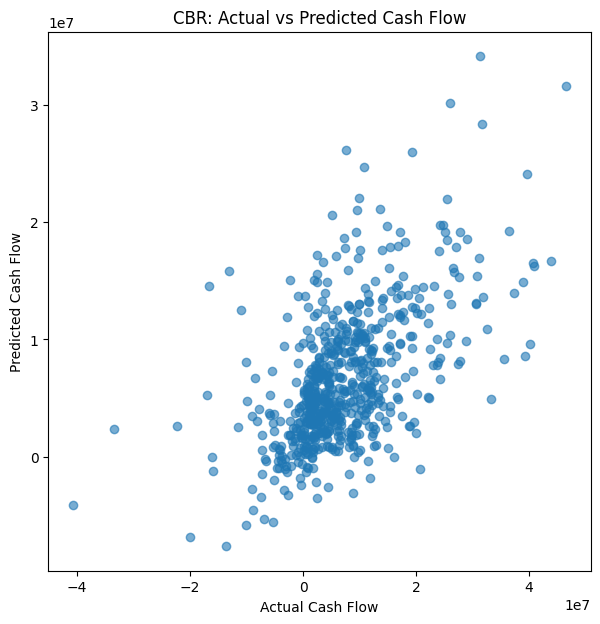

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Cash Flow")
plt.ylabel("Predicted Cash Flow")
plt.title("CBR: Actual vs Predicted Cash Flow")

plt.show()

In [19]:
test_index = 0

test_project = X_test.iloc[test_index]

print("Test project:")
print(test_project)

Test project:
project_type              Manufacturing
project_scale                    Medium
project_duration_years                9
complexity_index                   0.68
initial_investment          97927899.89
tax_rate                           0.17
risk_index                         0.67
year                                  1
inflation_rate                     0.06
market_growth_rate                 0.01
Name: 0, dtype: object


In [22]:
print("X_test_processed shape:", X_test_processed.shape)
print("test_index:", test_index)
print("Selected row shape:", X_test_processed[test_index].shape)
print("Model expects:", cbr_model.n_features_in_)

X_test_processed shape: (645, 17)
test_index: 0
Selected row shape: (17,)
Model expects: 17


In [23]:
distances, indices = cbr_model.kneighbors(
    X_test_processed[test_index:test_index + 1],
    n_neighbors=5
)

In [24]:
similar_projects = train_df.iloc[
    indices[0]
][[
    "project_id",
    "project_type",
    "project_scale",
    "project_duration_years",
    "initial_investment",
    "risk_index",
    "year",
    "cash_flow"
]].copy()

similar_projects["distance"] = distances[0]

similar_projects

,project_id,project_type,project_scale,project_duration_years,initial_investment,risk_index,year,cash_flow,distance
1852,P0285,Manufacturing,Medium,9,70749193.18,0.62,3,813324.25,1.944276
1789,P0276,Real Estate,Medium,10,20102263.27,0.68,1,-1247677.55,2.053607
746,P0115,Manufacturing,Small,10,47285652.16,0.64,2,4292433.28,2.064726
2563,P0393,Real Estate,Medium,9,55546769.34,0.43,1,-249474.85,2.085546
1135,P0178,Manufacturing,Medium,9,53142008.11,0.55,3,5672487.51,2.116810


In [25]:
results = {
    "model": "CBR",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

results

{'model': 'CBR',
 'MAE': 5711822.693349367,
 'RMSE': 8033359.443270371,
 'R2': 0.3203548231514105}

There's an important methodological point here.

Our dataset is project-year level, so the nearest-neighbor search above is finding similar project-year observations, not necessarily entire projects.

That's okay for this first implementation because our target is annual cash flow.

But a more sophisticated CBR system for your DSS could work at the whole-project level:

New Project
      ↓
Compare whole-project characteristics
      ↓
Find similar completed projects
      ↓
Look at their historical cash-flow trajectories
      ↓
Forecast new project's trajectory